
BATTERY INTRINSIC TRADING - COMPLETE EXAMPLE

Loading Order Book: 2024-01-01T00:30:00Z
Total active orders: 901
  Hour  2: 31 bids, 31 asks | Best bid: €56.59, Best ask: €32.82
  Hour  3: 20 bids, 25 asks | Best bid: €58.15, Best ask: €-0.57
  Hour  4: 7 bids, 10 asks | Best bid: €57.75, Best ask: €33.34
  Hour  5: 22 bids, 18 asks | Best bid: €56.29, Best ask: €-40.94
  Hour  6: 16 bids, 17 asks | Best bid: €48.84, Best ask: €26.80
  Hour  7: 15 bids, 15 asks | Best bid: €49.63, Best ask: €26.82
  Hour  8: 20 bids, 11 asks | Best bid: €52.03, Best ask: €37.73
  Hour  9: 18 bids, 21 asks | Best bid: €93.72, Best ask: €-6.17
  Hour 10: 18 bids, 19 asks | Best bid: €84.58, Best ask: €68.01
  Hour 11: 15 bids, 8 asks | Best bid: €87.20, Best ask: €74.84
  Hour 12: 14 bids, 21 asks | Best bid: €85.58, Best ask: €68.57
  Hour 13: 25 bids, 19 asks | Best bid: €92.06, Best ask: €66.21
  Hour 14: 25 bids, 26 asks | Best bid: €90.73, Best ask: €63.75
  Hour 15: 15 bids, 23 asks | Best bid: €89

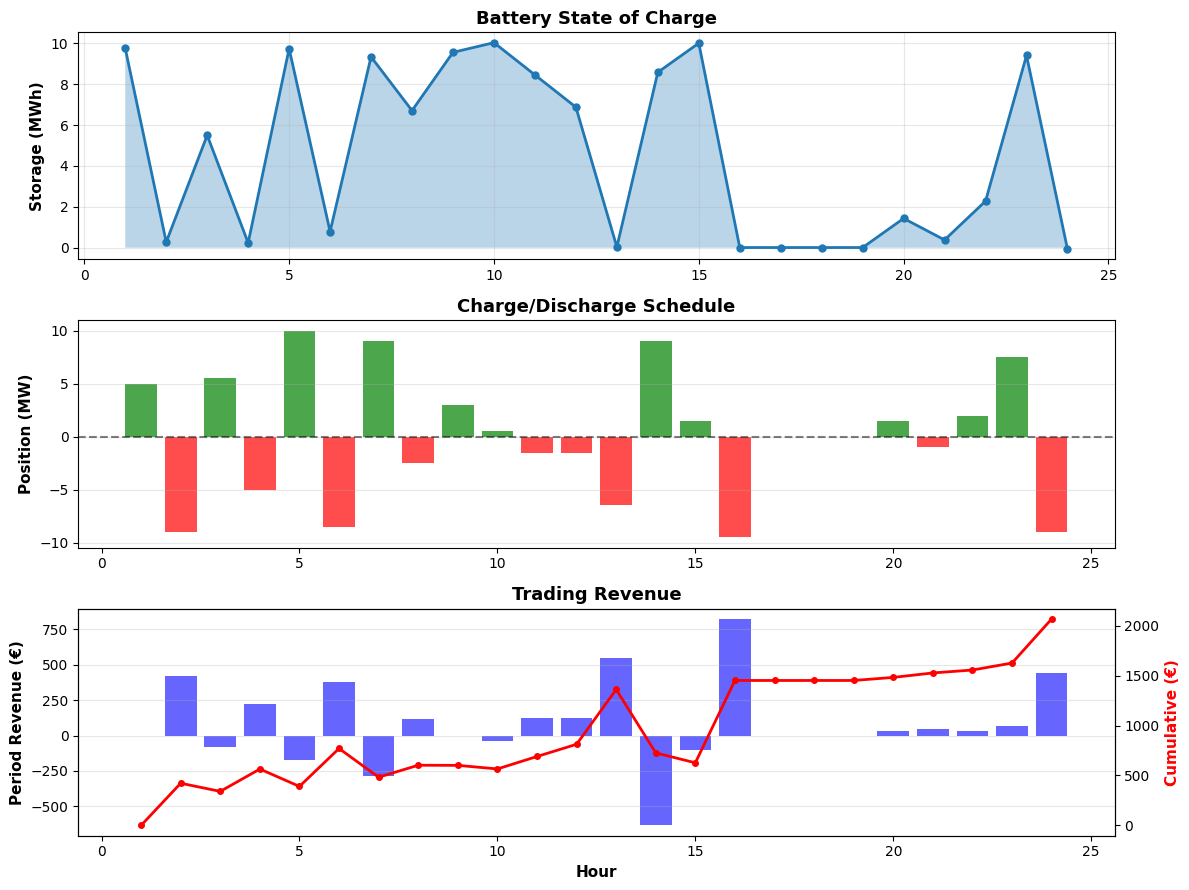


Period-by-Period Breakdown:
----------------------------------------------------------------------
Hour |  Storage | Position |    Revenue
----------------------------------------------------------------------
   1 |     9.75 |     5.00 | €     0.00
   2 |     0.28 |    -9.00 | €   422.14
   3 |     5.50 |     5.50 | €   -81.48
   4 |     0.24 |    -5.00 | €   223.66
   5 |     9.74 |    10.00 | €  -173.98
   6 |     0.79 |    -8.50 | €   379.91
   7 |     9.34 |     9.00 | €  -287.94
   8 |     6.71 |    -2.50 | €   120.08
   9 |     9.56 |     3.00 | €    -1.12
  10 |    10.03 |     0.50 | €   -36.01
  11 |     8.46 |    -1.50 | €   124.63
  12 |     6.88 |    -1.50 | €   122.18
  13 |     0.03 |    -6.50 | €   549.00
  14 |     8.58 |     9.00 | €  -635.02
  15 |    10.01 |     1.50 | €   -99.32
  16 |     0.01 |    -9.50 | €   824.44
  17 |     0.01 |     0.00 | €     0.00
  18 |     0.01 |     0.00 | €     0.00
  19 |     0.01 |     0.00 | €     0.00
  20 |     1.43 |     1.50 | 

In [1]:
"""
COMPLETE WORKING EXAMPLE
Battery Intrinsic Trading with Your CSV Format

Just update the csv_file path and run!
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import time

# ============================================================================
# PART 1: SIMPLE ORDER BOOK LOADER
# ============================================================================

def load_orderbook(csv_path, snapshot_time):
    """Load order book from your CSV format"""
    
    print(f"\n{'='*70}")
    print(f"Loading Order Book: {snapshot_time}")
    print(f"{'='*70}")
    
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Parse timestamps
    df['start'] = pd.to_datetime(df['start'])
    df['transaction'] = pd.to_datetime(df['transaction'])
    
    # Get delivery hour (1-24)
    df['hour'] = df['start'].dt.hour + 1
    
    # Filter active orders at snapshot time
    snapshot_dt = pd.to_datetime(snapshot_time)
    active = df[
        (df['transaction'] <= snapshot_dt) &  # Already submitted
        (df['start'] > snapshot_dt)           # Not yet delivered
    ]
    
    print(f"Total active orders: {len(active)}")
    
    # Build order book
    order_book = {}
    for hour in sorted(active['hour'].unique()):
        hour_orders = active[active['hour'] == hour]
        
        buy_orders = hour_orders[hour_orders['side'] == 'BUY']
        sell_orders = hour_orders[hour_orders['side'] == 'SELL']
        
        order_book[hour] = {
            'buy': [{'price': p, 'quantity': q} 
                   for p, q in zip(buy_orders['price'], buy_orders['quantity'])],
            'sell': [{'price': p, 'quantity': q}
                    for p, q in zip(sell_orders['price'], sell_orders['quantity'])]
        }
        
        best_bid = buy_orders['price'].max() if len(buy_orders) > 0 else None
        best_ask = sell_orders['price'].min() if len(sell_orders) > 0 else None
        
        bid_str = f"€{best_bid:.2f}" if best_bid is not None else "N/A"
        ask_str = f"€{best_ask:.2f}" if best_ask is not None else "N/A"
        
        print(f"  Hour {hour:2d}: {len(buy_orders)} bids, {len(sell_orders)} asks | "
              f"Best bid: {bid_str}, Best ask: {ask_str}")
    
    return order_book


# ============================================================================
# PART 2: SIMPLE DP SOLVER (STRIPPED DOWN VERSION)
# ============================================================================

class SimpleBatteryDP:
    """Simplified DP solver for quick testing"""
    
    def __init__(self):
        # Battery specs
        self.s_bar = 10.0      # Max storage (MWh)
        self.f_bar = 10.0      # Max power (MW)
        self.eta = 0.95        # Round-trip efficiency
        self.nu = 4.0          # Degradation cost (€/MWh)
        
        # DP parameters
        self.m = 21            # Storage grid points (fewer for speed)
        self.step = 0.5        # Trading step size (MWh)
        
        self.storage_grid = np.linspace(0, self.s_bar, self.m)
    
    def state_transition(self, s, f):
        """Update storage based on position"""
        return s + f * self.eta if f > 0 else s + f / self.eta
    
    def trade_cost(self, qty, orders, is_buy):
        """Calculate cost of trading quantity"""
        if qty <= 0:
            return 0
        
        remaining = qty
        cost = 0
        
        sorted_orders = sorted(orders, key=lambda x: x['price'], 
                              reverse=not is_buy)
        
        for order in sorted_orders:
            if remaining <= 0:
                break
            trade = min(remaining, order['quantity'])
            
            if is_buy:
                cost -= trade * (order['price'] + self.nu)
            else:
                cost += trade * (order['price'] - self.nu)
            
            remaining -= trade
        
        if remaining > 0:
            cost -= remaining * 999  # Penalty for unfilled
        
        return cost
    
    def solve(self, order_book, s_0=5.0):
        """Solve DP"""
        
        T = max(order_book.keys())
        print(f"\nSolving DP for {T} periods with {self.m} grid points...")
        
        # Initialize value functions
        V = {T+1: np.zeros(self.m)}
        policy = {}
        
        # Backward pass
        start = time.time()
        for t in range(T, 0, -1):
            V[t] = np.zeros(self.m)
            policy[t] = np.zeros(self.m)
            
            for i, s in enumerate(self.storage_grid):
                best_val = -1e9
                best_f = 0
                
                # Try different positions
                for f in np.arange(-self.f_bar, self.f_bar+0.1, self.step):
                    s_next = self.state_transition(s, f)
                    
                    # Check feasibility
                    if s_next < 0 or s_next > self.s_bar:
                        continue
                    
                    # Revenue from trading
                    if f > 0 and t in order_book:
                        rev = self.trade_cost(f, order_book[t]['sell'], True)
                    elif f < 0 and t in order_book:
                        rev = self.trade_cost(-f, order_book[t]['buy'], False)
                    else:
                        rev = 0
                    
                    # Value-to-go (linear interpolation)
                    idx = np.searchsorted(self.storage_grid, s_next)
                    if idx == 0:
                        v_next = V[t+1][0]
                    elif idx >= self.m:
                        v_next = V[t+1][-1]
                    else:
                        w = (s_next - self.storage_grid[idx-1]) / (
                            self.storage_grid[idx] - self.storage_grid[idx-1])
                        v_next = (1-w)*V[t+1][idx-1] + w*V[t+1][idx]
                    
                    total = rev + v_next
                    
                    if total > best_val:
                        best_val = total
                        best_f = f
                
                V[t][i] = best_val
                policy[t][i] = best_f
        
        print(f"Backward pass: {time.time()-start:.2f}s")
        
        # Forward pass
        results = {'hour': [], 'storage': [], 'position': [], 'revenue': []}
        s = s_0
        
        for t in range(1, T+1):
            # Find closest grid point
            i = np.argmin(np.abs(self.storage_grid - s))
            f = policy[t][i]
            
            # Calculate revenue
            if f > 0 and t in order_book:
                rev = self.trade_cost(f, order_book[t]['sell'], True)
            elif f < 0 and t in order_book:
                rev = self.trade_cost(-f, order_book[t]['buy'], False)
            else:
                rev = 0
            
            # Update state
            s = self.state_transition(s, f)
            
            results['hour'].append(t)
            results['storage'].append(s)
            results['position'].append(f)
            results['revenue'].append(rev)
        
        return results


# ============================================================================
# PART 3: VISUALIZATION
# ============================================================================

def plot_results(results):
    """Create simple result plots"""
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 9))
    hours = results['hour']
    
    # Storage
    axes[0].plot(hours, results['storage'], 'o-', linewidth=2, markersize=5)
    axes[0].fill_between(hours, 0, results['storage'], alpha=0.3)
    axes[0].set_ylabel('Storage (MWh)', fontsize=11, fontweight='bold')
    axes[0].set_title('Battery State of Charge', fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Position
    colors = ['green' if p>0 else 'red' if p<0 else 'gray' for p in results['position']]
    axes[1].bar(hours, results['position'], color=colors, alpha=0.7)
    axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[1].set_ylabel('Position (MW)', fontsize=11, fontweight='bold')
    axes[1].set_title('Charge/Discharge Schedule', fontsize=13, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    # Revenue
    axes[2].bar(hours, results['revenue'], color='blue', alpha=0.6)
    cumulative = np.cumsum(results['revenue'])
    ax2 = axes[2].twinx()
    ax2.plot(hours, cumulative, 'r-o', linewidth=2, markersize=4)
    
    axes[2].set_xlabel('Hour', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Period Revenue (€)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Cumulative (€)', fontsize=11, fontweight='bold', color='red')
    axes[2].set_title('Trading Revenue', fontsize=13, fontweight='bold')
    axes[2].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('battery_results.png', dpi=200)
    print("\n✓ Plot saved: battery_results.png")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Run complete example"""
    
    print("\n" + "="*70)
    print("BATTERY INTRINSIC TRADING - COMPLETE EXAMPLE")
    print("="*70)
    
    # ========== CONFIGURATION ==========
    CSV_FILE = '/Users/inderpal/Documents/power_market_data/bitepy/mycode/orderbook_2024-01-01.csv'              # <<< YOUR CSV FILE HERE
    SNAPSHOT_TIME = '2024-01-01T00:30:00Z'  # <<< SNAPSHOT TIMESTAMP
    INITIAL_STORAGE = 5.0                   # Starting at 50% capacity
    
    # ========== STEP 1: LOAD DATA ==========
    order_book = load_orderbook(CSV_FILE, SNAPSHOT_TIME)
    
    if not order_book:
        print("\n✗ No active orders found at snapshot time!")
        print("  Try a different timestamp or check your CSV.")
        return
    
    # ========== STEP 2: SOLVE DP ==========
    solver = SimpleBatteryDP()
    results = solver.solve(order_book, s_0=INITIAL_STORAGE)
    
    # ========== STEP 3: ANALYZE RESULTS ==========
    total_revenue = sum(results['revenue'])
    avg_storage = np.mean(results['storage'])
    
    print("\n" + "="*70)
    print("RESULTS SUMMARY")
    print("="*70)
    print(f"Total Revenue:     €{total_revenue:,.2f}")
    print(f"Average Storage:   {avg_storage:.2f} MWh")
    print(f"Max Storage:       {max(results['storage']):.2f} MWh")
    print(f"Min Storage:       {min(results['storage']):.2f} MWh")
    print(f"Charging periods:  {sum(1 for p in results['position'] if p > 0)}")
    print(f"Discharge periods: {sum(1 for p in results['position'] if p < 0)}")
    print("="*70)
    
    # ========== STEP 4: SAVE & VISUALIZE ==========
    df = pd.DataFrame(results)
    df.to_csv('results.csv', index=False)
    print("\n✓ Results saved: results.csv")
    
    plot_results(results)
    
    # ========== STEP 5: DETAILED BREAKDOWN ==========
    print("\nPeriod-by-Period Breakdown:")
    print("-"*70)
    print(f"{'Hour':>4} | {'Storage':>8} | {'Position':>8} | {'Revenue':>10}")
    print("-"*70)
    
    for i in range(len(results['hour'])):
        print(f"{results['hour'][i]:4d} | "
              f"{results['storage'][i]:8.2f} | "
              f"{results['position'][i]:8.2f} | "
              f"€{results['revenue'][i]:9.2f}")
    
    print("-"*70)
    print(f"{'TOTAL':>4} | {'':8} | {'':8} | €{total_revenue:9.2f}")
    print("="*70)


if __name__ == "__main__":
    main()